Use current stock data to create two potentially profitable investment portfolios. One that is higher risk and one that is lower risk
* You are to interpret and explain your interpretation of a high risk profile and low risk profile of a portfolio. You should provide some measurable quantitative data in your explanation

# Obtain data from yfinance

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import datetime as dt
import yfinance as yf

* A brief intro of yfinance *

In [3]:
# get stock data from past two year
start_date = dt.datetime.today() - dt.timedelta(days = 365 * 2)
end_date = dt.datetime.today()

# symbols for Microsoft (MSFT) and Apple (AAPL)
tickers = ['MSFT', 'AAPL']

# download data 
stock = yf.download(tickers, start=start_date, end=end_date)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  2 of 2 completed


In [4]:
stock.head()

Price            Close                    High                     Low  \
Ticker            AAPL        MSFT        AAPL        MSFT        AAPL   
Date                                                                     
2023-06-12  181.968063  326.768860  182.067078  327.015032  179.176026   
2023-06-13  181.492859  329.171539  182.324528  331.820354  180.631488   
2023-06-14  182.126526  332.174835  182.562167  333.848818  180.215665   
2023-06-15  184.166046  342.770111  184.671000  344.483460  181.958157   
2023-06-16  183.086868  337.088409  185.136355  346.088477  182.443318   

Price                         Open                 Volume            
Ticker            MSFT        AAPL        MSFT       AAPL      MSFT  
Date                                                                 
2023-06-12  320.181292  179.473055  323.548909   54274900  24260300  
2023-06-13  325.331260  180.987920  329.348776   54929100  22951300  
2023-06-14  327.714197  181.552274  329.220770   57462900  26003800  
2023-06-15  332.037011  182.136380  332.312723   65433200  38899100  
2023-06-16  336.714253  184.878923  345.940780  101235600  46533600

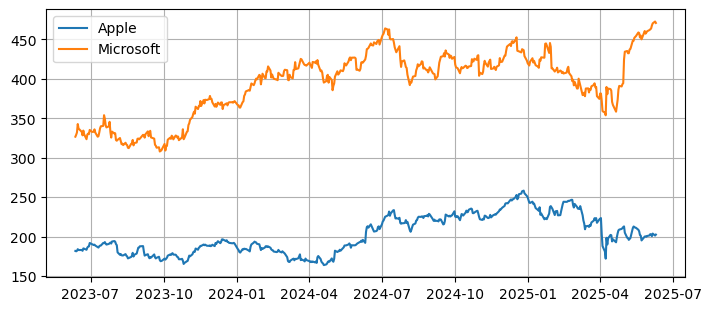

In [5]:
fig1, ax1 = plt.subplots(1, 1, figsize=[7, 3], layout='constrained')
ax1.plot(stock['Close']['AAPL'], label='Apple')
ax1.plot(stock["Close"]['MSFT'], label='Microsoft')
ax1.grid('on')
ax1.legend()


Noticed that the raw close price for Apple and Microsoft are not ideal for comparing the performance of investing each company, due to the bias of their stock price difference. To better compare the stock price change, we normalized the price to the first date in the data, which becomes the cumulated rate of return of the stock. 

In [6]:
# get close price for each day
close = stock['Close']
# get daily return by close_price(k)-close_price(0), and normalized to the price purchased
normalized_return = close / close.iloc[0] - 1

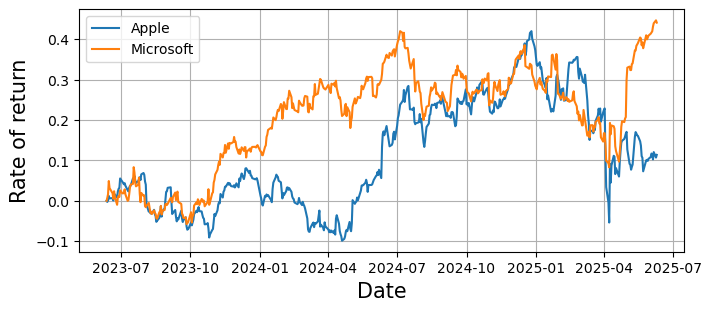

In [7]:
fig2, ax2 = plt.subplots(1, 1, figsize = [7,3], layout='constrained')
ax2.plot(normalized_return['AAPL'], label='Apple')
ax2.plot(normalized_return['MSFT'], label='Microsoft')
ax2.set_xlabel('Date', fontsize=15)
ax2.set_ylabel('Rate of return', fontsize=15)
ax2.legend()
ax2.grid('on')


Noticed that now the y-axis means the return per dollar investment on the first date for each stock. 

# Daily return of investments

In [8]:
# estimate the mean and variance of daily return
daily_return = (close / close.shift(1)).dropna()
daily_return_log = np.log(daily_return)

In [9]:
daily_return_log

Ticker,AAPL,MSFT
Date,,
2023-06-13,-0.002615,0.007326
2023-06-14,0.003485,0.009082
2023-06-15,0.011136,0.031399
2023-06-16,-0.005877,-0.016715
2023-06-20,0.000487,-0.012581
...,...,...
2025-06-04,-0.002216,0.001942
2025-06-05,-0.010856,0.008180
2025-06-06,0.016265,0.005757


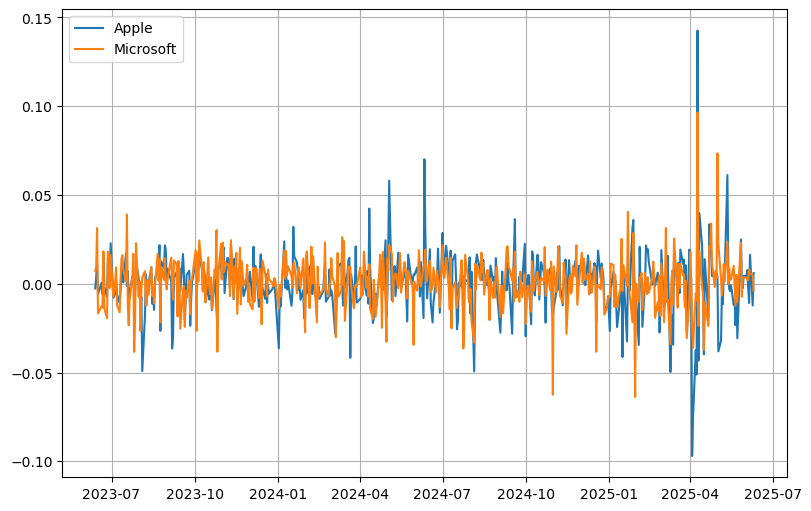

In [10]:
fig3, ax3 = plt.subplots(1, 1, figsize=[8, 5], layout='constrained')
ax3.plot(daily_return_log['AAPL'], label='Apple')
ax3.plot(daily_return_log['MSFT'], label='Microsoft')
ax3.legend()
ax3.grid('on')

In [11]:
np.std(daily_return_log, axis=0) * np.sqrt(252)

Ticker
AAPL    0.272698
MSFT    0.231314
dtype: float64

In [12]:
np.mean(daily_return_log, axis=0)

Ticker
AAPL    0.000215
MSFT    0.000731
dtype: float64

In [13]:
# make portfolio from two stock
w1 = 0.2  # investment ratio for Apple
w2 = 1 - w1  # investment ratio for Microsoft
portfolio_return = (
    w1 * normalized_return["AAPL"].values + w2 * normalized_return["MSFT"]
)

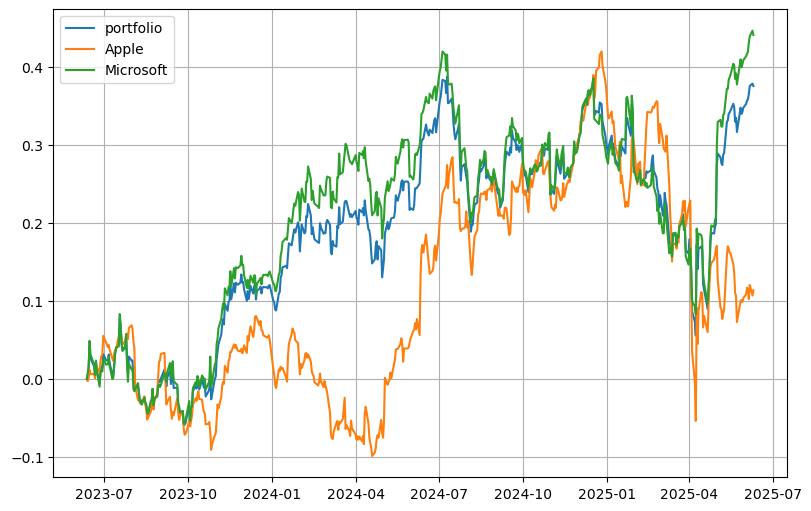

In [14]:
fig4, ax4 = plt.subplots(1, 1, figsize=[8, 5], layout="constrained")
ax4.plot(portfolio_return, label="portfolio")
ax4.plot(normalized_return["AAPL"], label="Apple")
ax4.plot(normalized_return["MSFT"], label="Microsoft")
ax4.legend()
ax4.grid("on")

In [15]:
portfolio_daily_return_log = (
    w1 * daily_return_log["AAPL"] + w2 * daily_return_log["MSFT"]
)

In [16]:
print(np.mean(portfolio_daily_return_log))
print(np.std(portfolio_daily_return_log) * np.sqrt(252))


0.0006277954324914545
0.21932597037662968


In [17]:
print(np.mean(daily_return_log, axis=0))
print(np.std(daily_return_log, axis=0) * np.sqrt(252))

Ticker
AAPL    0.000215
MSFT    0.000731
dtype: float64
Ticker
AAPL    0.272698
MSFT    0.231314
dtype: float64


We can use different diversification parameters between the two companies and constructed various protfolios. 

In [18]:
portfolio_return_log_mean = []
portfolio_return_log_std = []
w1_list = np.arange(0, 1, 0.01)
for w1 in w1_list:
    w2 = 1 - w1
    portfolio_daily_return_log = (
        w1 * daily_return_log["AAPL"] + w2 * daily_return_log["MSFT"]
    )
    portfolio_return_log_mean.append(np.mean(portfolio_daily_return_log))
    portfolio_return_log_std.append(np.std(portfolio_daily_return_log) * np.sqrt(252))

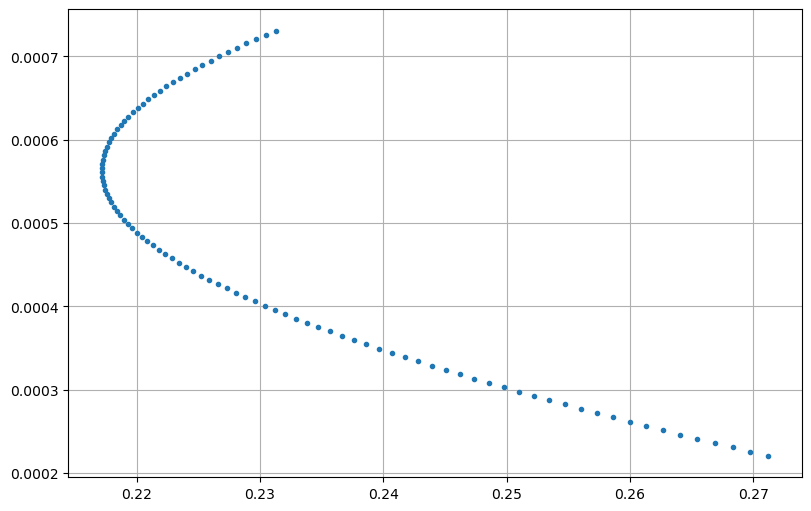

In [19]:
fig5, ax5 = plt.subplots(1, 1, figsize=[8, 5], layout="constrained")
ax5.plot(portfolio_return_log_std, portfolio_return_log_mean, ".")
ax5.grid("on")

The risk-return plot clearly show that tehir exsist a specific portfolio such that the risk of the entire portfolio is minimized. This can be formulated as follow:

Suppose the daily return rate of stock 1 is represented by a random variable $X_1$ with mean and variance $\mu_1$ and $\sigma_1^2$. Similarly for stock 2. The construction of portfolio is done by diversify investment to each stock with weight $w_1, w_2$ where $w_1 + w_2=1$, denoated as $P=w_1X_1+w_2X_2$. The expected return and varaince of portofolio is thus
$$
\begin{aligned}
  E(P)&=w_1E(X_1)+w_2E(X_2)=w_1\mu_1+w_2\mu_2\\
  \mathrm{Var}(P)&=\mathrm{Var}(w_1X_1+w_2X_2)=w_1^2\mathrm{Var}(X_1)+w_2^2\mathrm{Var}(X_2)+2w_1w_2\mathrm{Cov}(X_1, X_2)\\
  &=w_1^2\sigma^2_1+w_2^2\sigma^2_2+2w_1\sigma_1w_2\sigma_2\rho_{12}
\end{aligned}
$$
The risk of portfolio is in general not the linear combination of the risk of each stock due to nonlinearity of variance. However, when the two stock are perfectly positive correlated ($\rho_{12}=1$), then $\mathrm{Var}(P)=(w_1\sigma_1+w_2\sigma_2)^2$ and the standard deviation of portfolio become the weighted average of composed stock risk. On the other hand, if the two stock are perfectly negtive correlated, then the standard deviation of portfolio become $\sigma_P=w_1\sigma_1-w_2\sigma_2$. In this case, it possible to find a specific portfolio with no risk. 

In reality, it is impossible to achive pefect correlation. Thus, in general, the varaince can be expressed in a quadratic form under condition $w_1+w_2=1$:
$$
\mathrm{Var}(P)=w_2^2(\sigma^2_1+\sigma^2_2-2\sigma_1\sigma_2\rho_{12}) + 2w_2(\sigma_1\sigma_2\rho_{12}-\sigma^2_1)+\sigma^2_1
$$
which has globle minimum at $w^*_2=\frac{\sigma^2_1-\sigma_1\sigma_2\rho_{12}}{\sigma^2_1+\sigma^2_2-2\sigma_1\sigma_2\rho_{12}}$. 
* Notide that the globle minimum is not alwasy attained under the condition that $w_2\in[0, 1]$

In [20]:
cov = daily_return_log.cov() * 252
sigma1 = np.sqrt(cov.iloc[0, 0])
sigma2 = np.sqrt(cov.iloc[1, 1])
rho12 = cov.iloc[0, 1] / (sigma1 * sigma2)
w2_min = (sigma1**2 - sigma1 * sigma2 * rho12) / (
    sigma1**2 + sigma2**2 - 2 * sigma1 * sigma2 * rho12
)
w1_min = 1 - w2_min

In [21]:
portfolio_daily_return_log_min = (
    w1_min * daily_return_log["AAPL"] + w2_min * daily_return_log["MSFT"]
)
portfolio_daily_return_log_min_mean = np.mean(portfolio_daily_return_log_min)
portfolio_daily_return_log_min_std = np.std(portfolio_daily_return_log_min) * np.sqrt(
    252
)

In [22]:
portfolio_daily_return_log_min_std

0.217159607658741

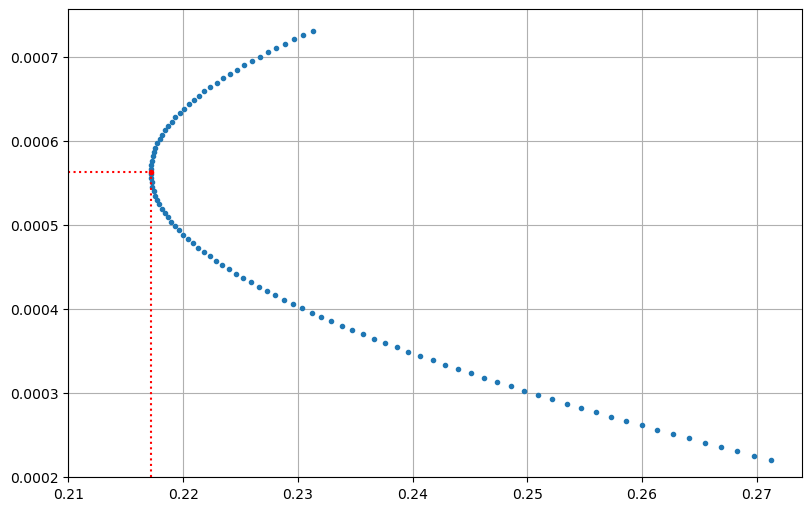

In [23]:
fig6, ax6 = plt.subplots(1, 1, figsize=[8, 5], layout="constrained")
ax6.plot(portfolio_return_log_std, portfolio_return_log_mean, ".")
ax6.plot(
    portfolio_daily_return_log_min_std, portfolio_daily_return_log_min_mean, ".", c="r"
)
ax6.set_xlim(xmin=0.21)
ax6.set_ylim(ymin=0.0002)
ax6.hlines(
    y=portfolio_daily_return_log_min_mean,
    xmin=ax6.get_xlim()[0],
    xmax=portfolio_daily_return_log_min_std,
    linestyles=":",
    colors="r"
)
ax6.vlines(
    x=portfolio_daily_return_log_min_std,
    ymin=ax6.get_ylim()[0],
    ymax=portfolio_daily_return_log_min_mean,
    linestyles=":",
    color="r",
)
ax6.grid("on")

More generally, if we considered a investment diversification of $n$ stocks with weight $\mathbf{w}=[w_1, w_2, \cdots, w_n]^T, \sum_i w_i=1$.
$$
P=w_1X_1+w_2X_2+\cdots+w_nX_n
$$
the mean return of the portfolio will be
$$
E(P)=w_1E(X_1)+w_2E(X_2)+\cdots+w_nE(X_n)
$$
which is the weighted average of the return of each stock. The risk of the portfolio is
$$
\mathrm{Var}(P)=\mathrm{Var}(w_1E(X_1)+w_2E(X_2)+\cdots+w_nE(X_n))=\sum_iw_i^2\mathrm{Var}(X_i)+2\sum_{i\neq j}w_iw_j\mathrm{Cov}(X_i, X_j)\\
=\mathbf{w}^T K \mathbf{w}
$$
where
$$
K=\begin{pmatrix}
\sigma_1^2&\mathrm{Cov}(X_1, X_2)&\cdots&\mathrm{Cov}(X_1, X_n)\\
\mathrm{Cov}(X_2, X_1)&\sigma_2^2&\cdots&\mathrm{Cov}(X_2, X_n)\\
\vdots&\vdots&\ddots&\vdots\\
\mathrm{Cov}(X_n, X_1)&\cdots&\cdots&\sigma_n^2
\end{pmatrix}
$$
is the covariance matrix. The risk of the portfolio is in quadratic form and can be minizmed under the constrain $\sum_iw_i=1$

In [24]:
# get stock data from past two year
start_date = dt.datetime.today() - dt.timedelta(days = 365 * 2)
end_date = dt.datetime.today()

# symbols for Microsoft (MSFT) and Apple (AAPL)
multi_tickers = ['MSFT', 'AAPL', 'AMD', 'IBM', 'INTC', 'NVDA', 'AMZN']
n_stocks = len(multi_tickers)

# download data 
multi_stock = yf.download(multi_tickers, start=start_date, end=end_date)


[*********************100%***********************]  7 of 7 completed


In [25]:
multi_close = multi_stock['Close']
multi_daily_return_log = np.log(multi_close/multi_close.shift(1)).dropna()

In [26]:
multi_daily_return_log

Ticker,AAPL,AMD,AMZN,IBM,INTC,MSFT,NVDA
Date,,,,,,,
2023-06-13,-0.002615,-0.036738,0.000711,0.008613,0.025083,0.007326,0.038264
2023-06-14,0.003485,0.022236,-0.001897,-0.002911,0.048074,0.009083,0.047022
2023-06-15,0.011136,-0.024567,0.005443,0.008708,0.006723,0.031398,-0.008033
2023-06-16,-0.005877,-0.034057,-0.012827,-0.006670,0.015238,-0.016714,0.000914
2023-06-20,0.000487,-0.009623,0.002308,-0.011118,-0.038396,-0.012581,0.025805
...,...,...,...,...,...,...,...
2025-06-04,-0.002216,0.010768,0.007362,0.001206,-0.001973,0.001942,0.004945
2025-06-05,-0.010856,-0.024674,0.003276,0.005034,-0.012923,0.008180,-0.013692
2025-06-06,0.016265,0.004313,0.026859,0.007504,0.003496,0.005757,0.012282


In [41]:
multi_daily_return_log.mean()

Ticker
AAPL    0.000215
AMD    -0.000094
AMZN    0.001084
IBM     0.001554
INTC   -0.000768
MSFT    0.000731
NVDA    0.002588
dtype: float64

In [42]:
multi_daily_return_log.std() * np.sqrt(252)

Ticker
AAPL    0.272971
AMD     0.491110
AMZN    0.312642
IBM     0.243127
INTC    0.532579
MSFT    0.231546
NVDA    0.518447
dtype: float64

In [64]:
w = np.repeat(1/n_stocks, n_stocks)[:, np.newaxis]
portfolio_daily_return_log_multi = multi_daily_return_log @ w
portfolio_daily_return_log_multi=portfolio_daily_return_log_multi.rename(columns={0:'portfolio return'})

In [65]:
portfolio_daily_return_log_multi

,portfolio return
Date,
2023-06-13,0.005806
2023-06-14,0.017870
2023-06-15,0.004401
2023-06-16,-0.008570
2023-06-20,-0.006160
...,...
2025-06-04,0.003147
2025-06-05,-0.006522
2025-06-06,0.010925


In [66]:
portfolio_daily_return_log_multi.mean()

portfolio return    0.000759
dtype: float64

In [67]:
portfolio_daily_return_log_multi.std() * np.sqrt(252)

portfolio return    0.26676
dtype: float64

In [68]:
cov_mat = multi_daily_return_log.cov() * 252

<Axes: xlabel='Ticker', ylabel='Ticker'>

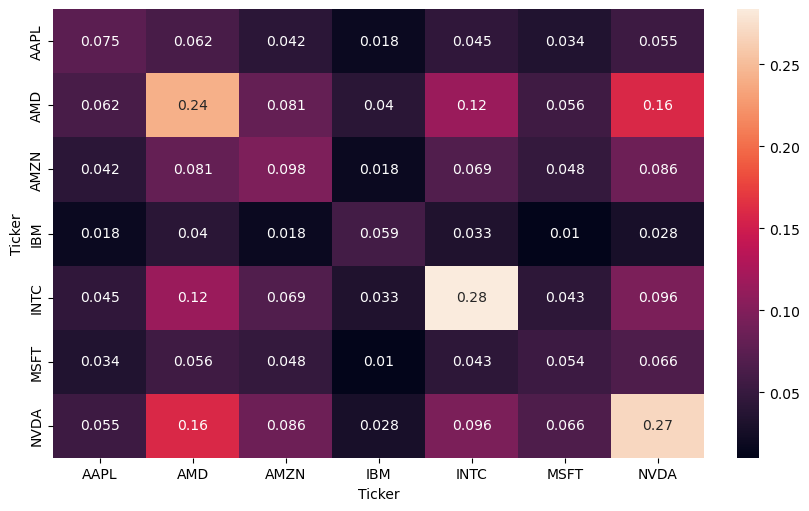

In [70]:
fig7, ax7 = plt.subplots(1, 1, figsize=[8, 5], layout='constrained')
sns.heatmap(cov_mat, ax=ax7, annot=True)

In [78]:
from scipy.optimize import minimize

init_w = w.flatten()

def portfolio_std(w):
    return np.sqrt(w.T @ cov_mat @ w)

constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
               {'type': 'ineq', 'fun': lambda w: np.min(w)})

minimize_result = minimize(portfolio_std, init_w, constraints=constraints)

# Optimal asset weights
optimal_weights = minimize_result.x

# Print the optimal weights and expected returns
optimal_weights

array([ 1.28341724e-01, -4.65711523e-19,  9.83344657e-03,  4.30602515e-01,
        1.26677847e-05,  4.31208451e-01,  1.19606576e-06])

In [80]:
portfolio_daily_return_log_multi_optimal = multi_daily_return_log @ optimal_weights[:, np.newaxis]

In [81]:
portfolio_daily_return_log_multi_optimal.mean()

0    0.001023
dtype: float64

In [82]:
portfolio_daily_return_log_multi_optimal.std() * np.sqrt(252)

0    0.179793
dtype: float64